# Signature Kernel — full-rank, dynamic programming

The exact truncated signature kernel ([Király & Oberhauser, JMLR 2019](https://jmlr.org/papers/volume20/16-314/16-314.pdf), Alg. 3 & 6): lift a static kernel on $\mathbb{R}^d$ to a kernel on sequences. This is the headline 'plain vanilla' kernel; the `order` knob is the embedding-order cap (1 = fast first-order path, >1 = higher-order).

## Environment
Detect the live backend/device and whether a SYCL fast-path is available.

In [1]:
import sys, pathlib
# Make `_nbtools` and the in-repo `ksig` importable whether the notebook is
# launched from ./notebooks or from the repo root (no `pip install` needed).
_nbdir = pathlib.Path.cwd()
_root = _nbdir.parent if (_nbdir / "_nbtools.py").exists() else _nbdir
_nbdir = _root / "notebooks"
for _p in (str(_nbdir), str(_root)):
    if _p not in sys.path:
        sys.path.insert(0, _p)

import numpy as np
import ksig
import _nbtools as nb
%matplotlib inline

ENV = nb.detect_env()
nb.print_env_banner(ENV)

[2026-06-02 01:17:30,081] [INFO] [real_accelerator.py:260:get_accelerator] Setting ds_accelerator to xpu (auto detect)


icx: warning: -Wl,-z,noexecstack,-z,relro,-z,now,-rpath,$ORIGIN/../..,-rpath,$ORIGIN/../../..: 'linker' input unused [-Wunused-command-line-argument]
icx: warning: -Wl,-z,noexecstack,-z,relro,-z,now,-rpath,$ORIGIN/../..,-rpath,$ORIGIN/../../..: 'linker' input unused [-Wunused-command-line-argument]
/usr/bin/ld: /var/tmp/pbs.8519295.aurora-pbs-0001.hostmgmt.cm.aurora.alcf.anl.gov/claude-35813/tmppog5s4my/test.o: in function `main':
test.c:(.text+0x25): undefined reference to `io_pgetevents'
icx: error: linker command failed with exit code 1 (use -v to see invocation)


/opt/aurora/25.190.0/frameworks/aurora_frameworks-2025.2.0/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[2026-06-02 01:17:34,854] [INFO] [logging.py:107:log_dist] [Rank -1] [TorchCheckpointEngine] Initialized with serialization = False


ksig backend : torch  |  device: xpu  |  SYCL: available  |  ksig unknown


## Deterministic input
`simulate(16, 20, 3, seed=0)` — a batch of integrated random walks (portable: the NumPy RNG is bit-identical on every machine, so the values below are reproducible on Aurora).

In [2]:
X = nb.simulate(16, 20, 3, seed=0)
print('X shape:', X.shape, '| dtype:', X.dtype)

X shape: (16, 20, 3) | dtype: float64


## Compute the kernel

```python
sig = ksig.kernels.SignatureKernel(n_levels=4, order=2, normalize=True, static_kernel=ksig.static.kernels.RBFKernel())
K = sig(X)
print("gram shape :", tuple(K.shape))
print("K[:3,:3]   :\n", np.round(nb.as_host(K)[:3, :3], 4))
print("diag mean  :", round(float(np.diag(nb.as_host(K)).mean()), 6))
```

**Reference output — NVIDIA H100 NVL (CuPy 14.1.0), kwargs: `n_levels=4, order=2, normalize=True, static=RBF`:**

```text
gram shape : (16, 16)
K[:3,:3]   :
 [[1.     0.2291 0.2158]
 [0.2291 1.     0.305 ]
 [0.2158 0.305  1.    ]]
diag mean  : 1.0
```

Running the next cell on the target machine should reproduce this to ~1e-8 in
float64 (`diag == 1` exactly when `normalize=True`).

In [3]:
sig = ksig.kernels.SignatureKernel(n_levels=4, order=2, normalize=True, static_kernel=ksig.static.kernels.RBFKernel())
K = sig(X)
print("gram shape :", tuple(K.shape))
print("K[:3,:3]   :\n", np.round(nb.as_host(K)[:3, :3], 4))
print("diag mean  :", round(float(np.diag(nb.as_host(K)).mean()), 6))

gram shape : (16, 16)
K[:3,:3]   :
 [[1.     0.2291 0.2158]
 [0.2291 1.     0.305 ]
 [0.2158 0.305  1.    ]]
diag mean  : 1.0


## Scaling — green = CUDA reference, blue = this machine

The cell below sweeps **sequence length L  (n=32, d=3, n_levels=4, order=2)** and times each point on whatever backend
is live, then overlays:

* 🟩 **green** — the frozen reference measured on **NVIDIA H100 NVL** (`cuda_reference.json`),
* 🟦 **blue** — what *this* machine computes now (torch-native on Aurora XPU / CUDA / CPU),
> This kernel has **no SYCL fast-path** — only SigPDE / GAK / RWS dispatch to
> `ksig._sycl` — so there is no orange curve here, just green vs blue.

The grid and the knobs at the top of the cell are **tunable** — they default to
the reference grid so blue lines up with green; widen them to push the frontier.

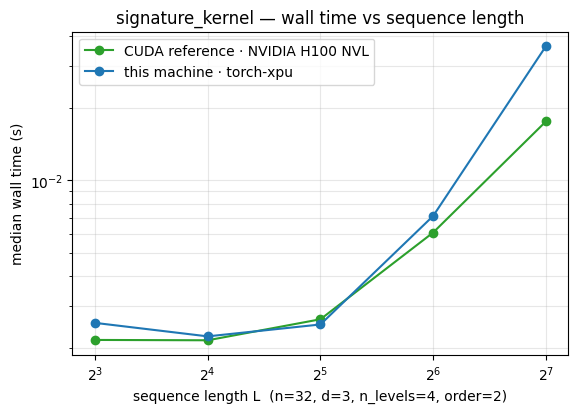

In [4]:
# --- tunable knobs (default to the CUDA-reference grid) ---------------------
L_GRID = [8, 16, 32, 64, 128]          # sequence lengths to sweep
N, D   = 32, 3                 # fixed batch size / channels
REPS   = 5
N_LEVELS = 4
ORDER = 2                         # embedding-order cap (1, 2, 3, ...)

def time_one(L):
    Xs = nb.simulate(N, L, D, seed=1)
    k = ksig.kernels.SignatureKernel(n_levels=N_LEVELS, order=ORDER, normalize=True, static_kernel=ksig.static.kernels.RBFKernel())
    return nb.timeit(lambda: k(Xs), reps=REPS, device=ENV["device"])

# This kernel has no SYCL fast-path (only SigPDE / GAK / RWS dispatch to
# ksig._sycl), so there is no orange curve -- just green vs blue.
times = [time_one(L) for L in L_GRID]
nb.scaling_plot(L_GRID, times, "signature_kernel", title="signature_kernel — wall time vs sequence length");